# ML - REGRESION LINEAL

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## Paso 1: Definicion del problema (target)
Predecir el coste del seguro medico de un cliente, la tenemos localizada en la variable `charges`

## Paso 2: Recopilacion de datos
[fuente](https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv)

### Importamos los datos y creamos el DataFrame

In [3]:
df = pd.read_csv('../data/raw/medical_insurance_cost.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Paso 3: Realizamos un EDA completo

### Analisis descriptivo

In [4]:
# Obtenemos las dimensiones
df.shape

(1338, 7)

In [5]:
# Obtenemos informacion sobre el tipo de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
# Obtenemos información estadística de las variables numércias
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


> ## Observaciones:
>
> - Existen un total de 1338 filas (en este caso, clientes) y 7 columnas, entre las cuales está el target a predecir, `charges`
> - Todas las columnas cuentan siempre con valor, no tienen valores nulos.
> - Los datos constan de 4 variables numéricas y 3 categóricas

### Limpieza de datos

In [7]:
# Comprobamos si hay valores duplicados
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
df[df['charges'] == 1639.5631]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [9]:
df.drop_duplicates(inplace=True)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


> ## Conclusiones:

### Análisis de Variables

#### Análisis de Variables Univariantes Categóricas

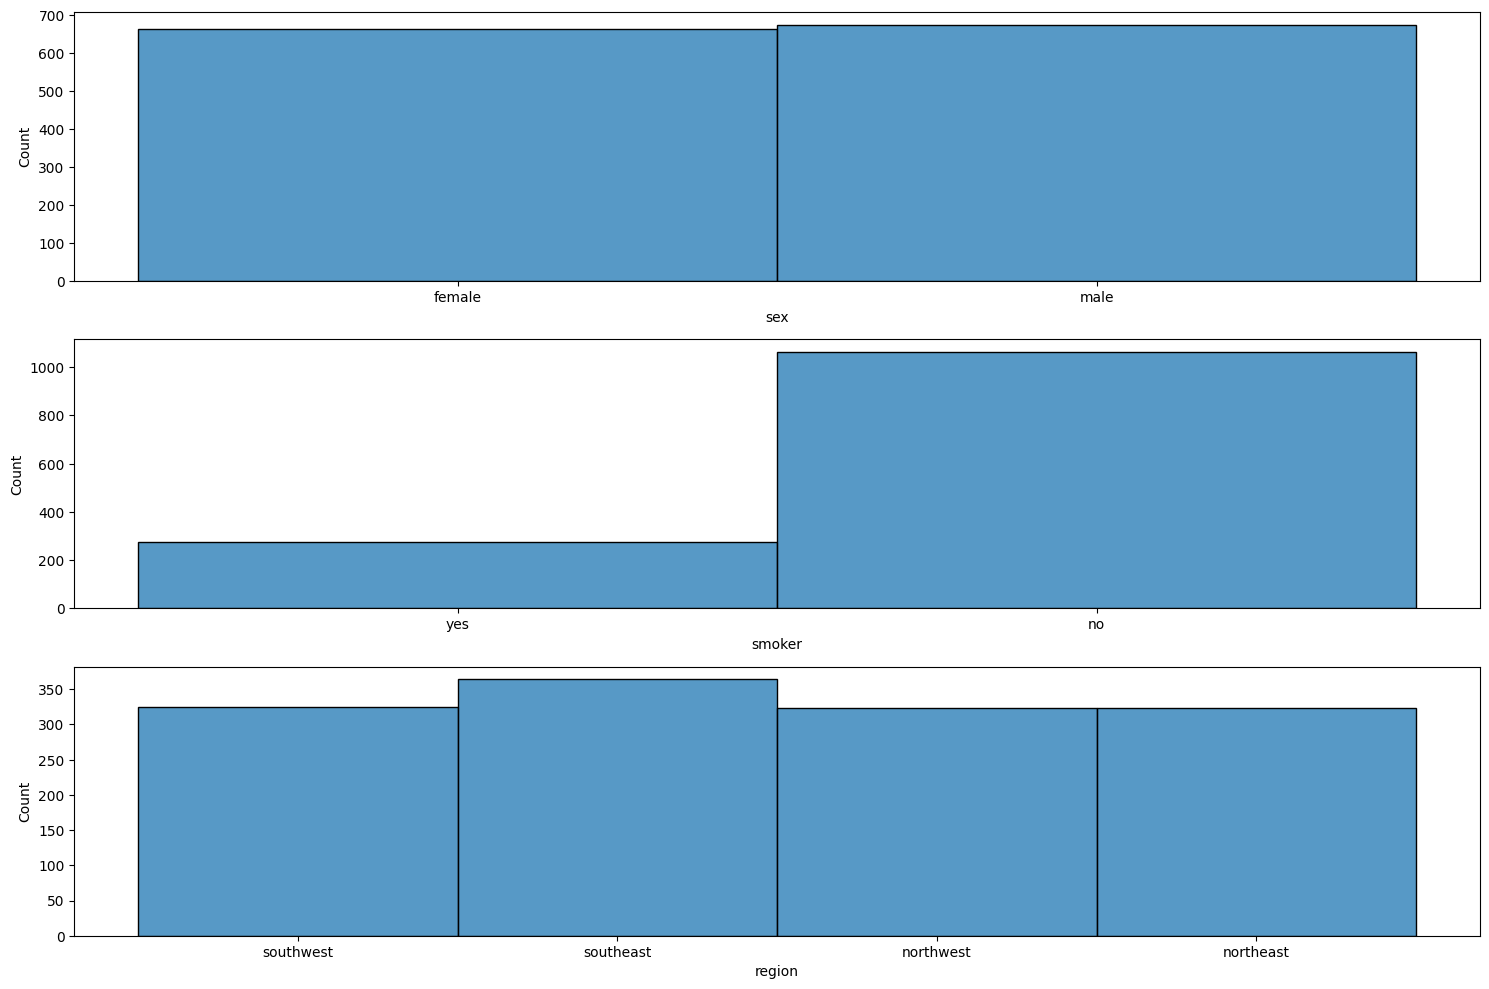

In [10]:
fig, axis = plt.subplots(3, 1, figsize=(15, 10))

sns.histplot(ax=axis[0], data=df, x='sex')
sns.histplot(ax=axis[1], data=df, x='smoker')
sns.histplot(ax=axis[2], data=df, x='region')

#fig.delaxes(ax=axis[3, 1])
plt.tight_layout()

#### Análisis de Variables Univariantes Numéricas

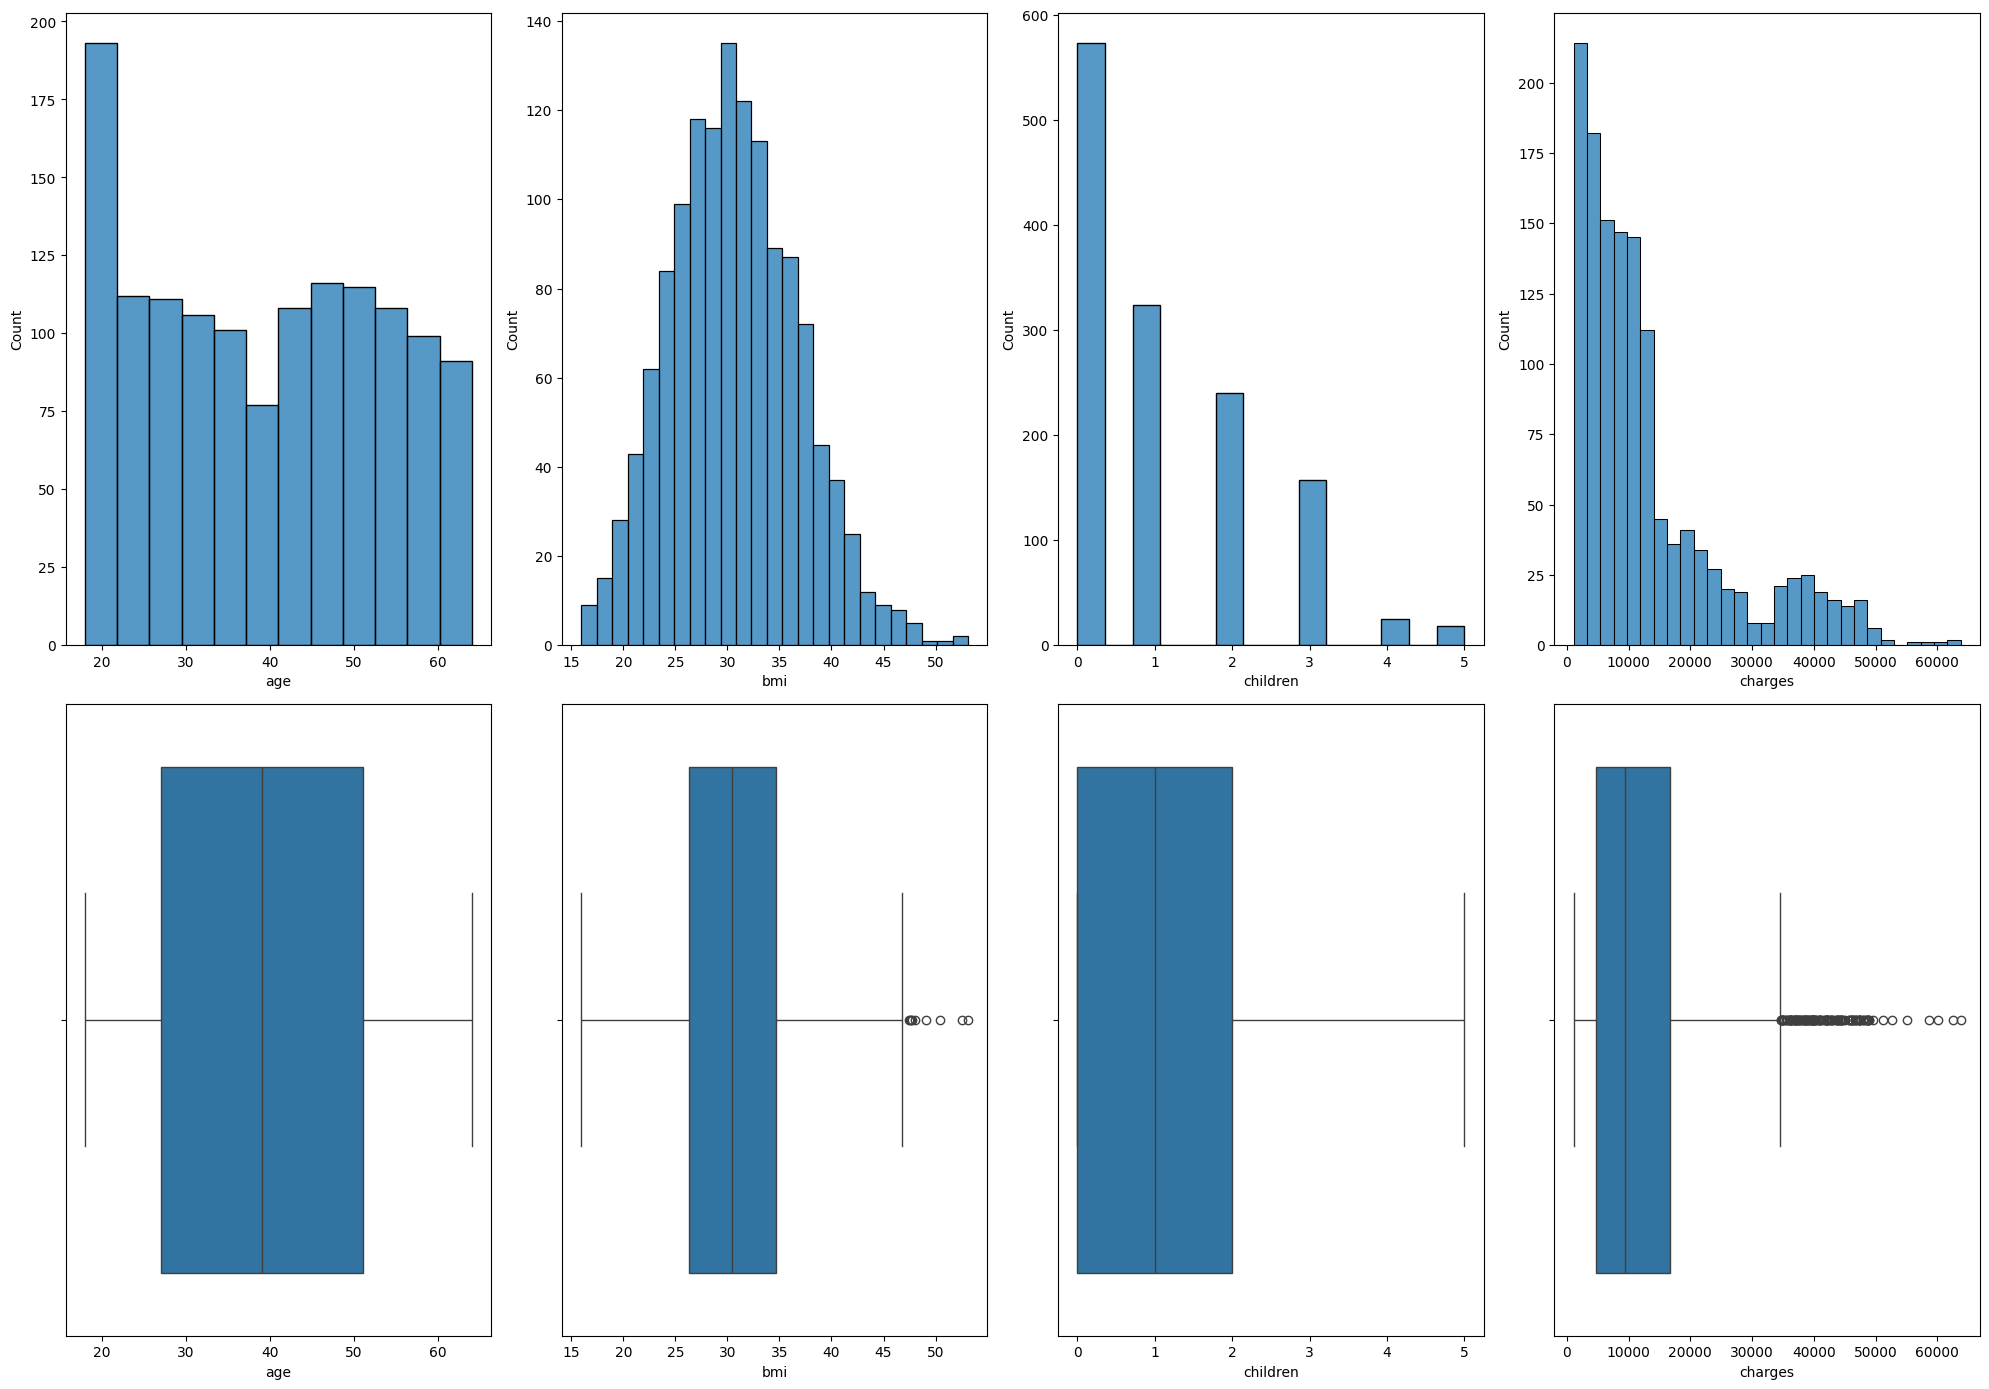

In [11]:
fig, axis = plt.subplots(2, 4, figsize=(20, 14))

sns.histplot(ax=axis[0, 0], data=df, x='age')
sns.boxplot(ax=axis[1, 0], data=df, x='age')
sns.histplot(ax=axis[0, 1], data=df, x='bmi')
sns.boxplot(ax=axis[1, 1], data=df, x='bmi')
sns.histplot(ax=axis[0, 2], data=df, x='children')
sns.boxplot(ax=axis[1, 2], data=df, x='children')
sns.histplot(ax=axis[0, 3], data=df, x='charges')
sns.boxplot(ax=axis[1, 3], data=df, x='charges')

plt.tight_layout()

#### Análisis de Variables Multivariante (numerico-numerico)

    charges - (age, bmi, children)

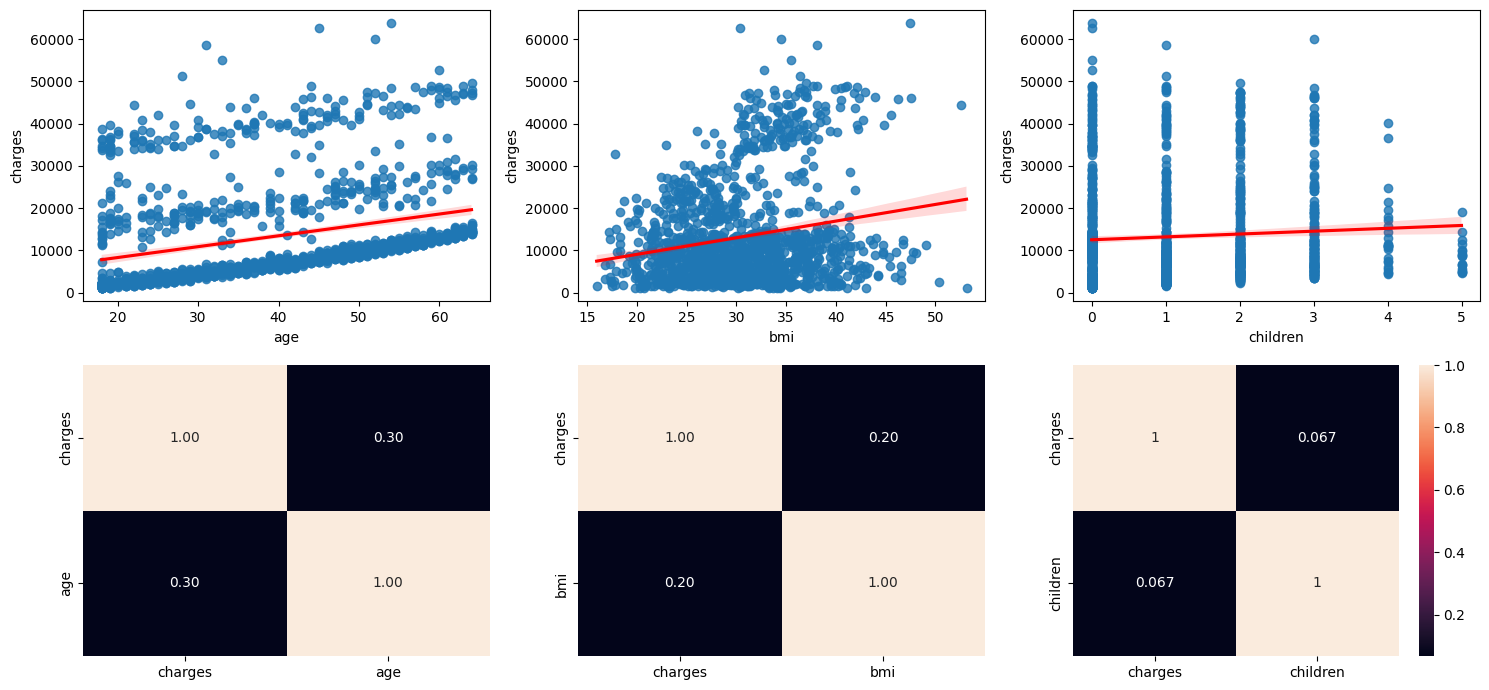

In [15]:
fig, axis = plt.subplots(2, 3, figsize=(15,7))

sns.regplot(ax=axis[0, 0], data=df, x='age', y='charges', line_kws={'color': 'red'})
sns.heatmap(df[['charges', 'age']].corr(), annot=True, fmt='.2f', ax=axis[1, 0], cbar=False)
sns.regplot(ax=axis[0, 1], data=df, x='bmi', y='charges', line_kws={'color': 'red'})
sns.heatmap(df[['charges', 'bmi']].corr(), annot=True, fmt='.2f', ax=axis[1, 1], cbar=False)
sns.regplot(ax=axis[0, 2], data=df, x='children', y='charges', line_kws={'color': 'red'})
sns.heatmap(df[['charges', 'children']].corr(), annot=True, ax=axis[1, 2])

plt.tight_layout()

#### Análisis de Variables Multivariante (numerico-categórico completo) 

In [ ]:
# Creo columnas numéricas para las variables categóricas
df['sex_n'] = pd.factorize(df['sex'])[0]
df['smoker_n'] = pd.factorize(df['smoker'])[0]
df['region_n'] = pd.factorize(df['region'])[0]
df

,age,sex,bmi,children,smoker,region,charges,sex_n,smoker_n,region_n
0,19,female,27.900,0,yes,southwest,16884.92400,0,0,0
1,18,male,33.770,1,no,southeast,1725.55230,1,1,1
2,28,male,33.000,3,no,southeast,4449.46200,1,1,1
3,33,male,22.705,0,no,northwest,21984.47061,1,1,2
4,32,male,28.880,0,no,northwest,3866.85520,1,1,2
...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,1,1,2
1334,18,female,31.920,0,no,northeast,2205.98080,0,1,3
1335,18,female,36.850,0,no,southeast,1629.83350,0,1,1
1336,21,female,25.800,0,no,southwest,2007.94500,0,1,0


<Axes: >

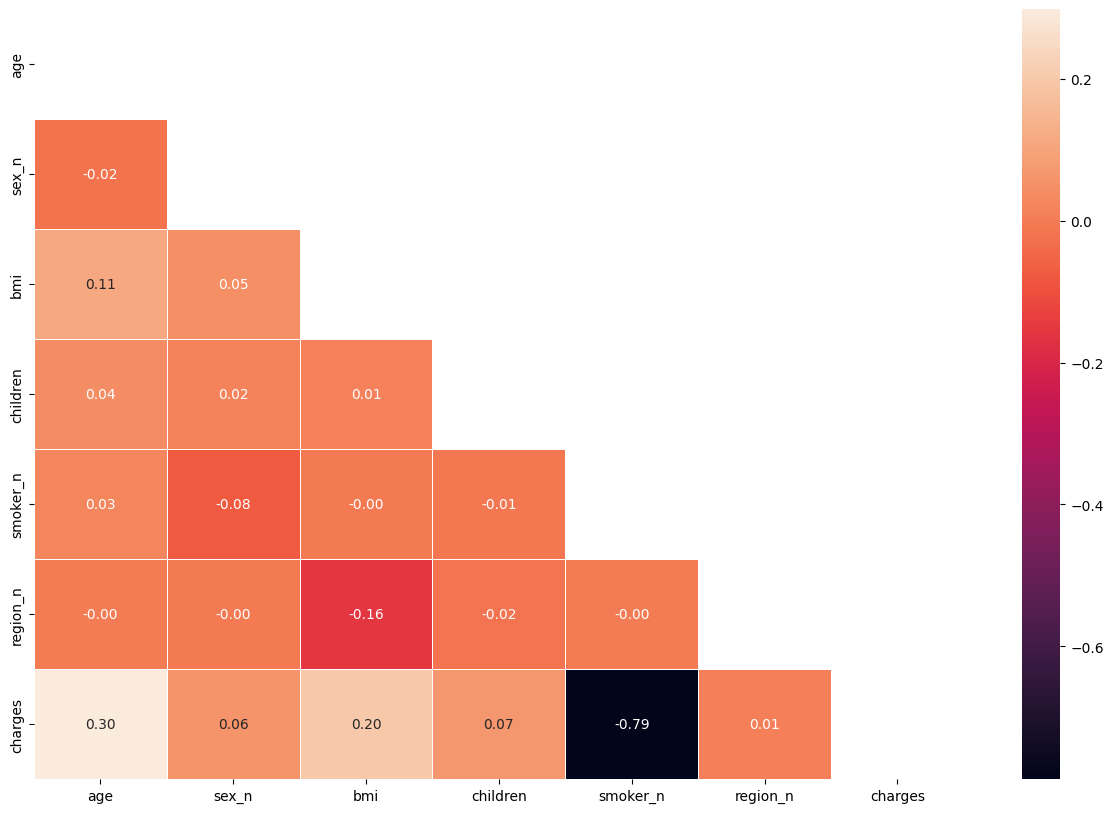

In [ ]:
corr = df[['age', 'sex_n', 'bmi', 'children', 'smoker_n', 'region_n', 'charges']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt='.2f')

### Ingeniería de características

#### Análisis de outliers

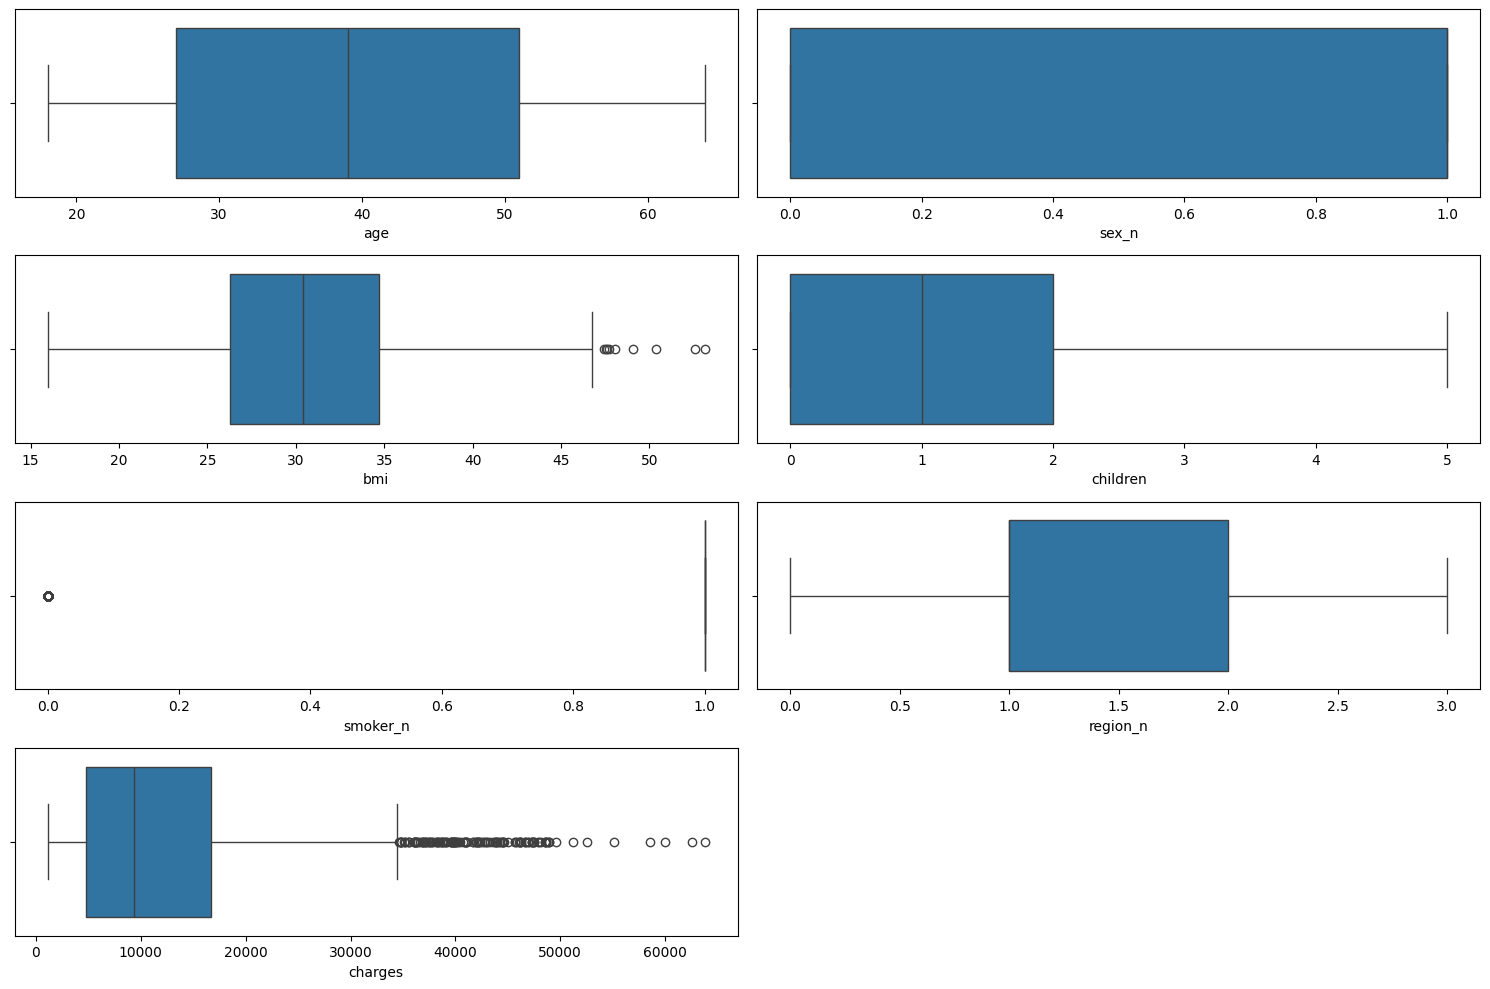

In [28]:
# corr = df[['age', 'sex_n', 'bmi', 'children', 'smoker_n', 'region_n', 'charges']].corr()
fig, axis = plt.subplots(4, 2, figsize=(15, 10))

sns.boxplot(ax=axis[0, 0], data=df, x='age')
sns.boxplot(ax=axis[0, 1], data=df, x='sex_n')
sns.boxplot(ax=axis[1, 0], data=df, x='bmi')
sns.boxplot(ax=axis[1, 1], data=df, x='children')
sns.boxplot(ax=axis[2, 0], data=df, x='smoker_n')
sns.boxplot(ax=axis[2, 1], data=df, x='region_n')
sns.boxplot(ax=axis[3, 0], data=df, x='charges')

plt.delaxes(ax=axis[3, 1])
plt.tight_layout()

#### Análisis de valores faltantes

In [30]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
sex_n       0
smoker_n    0
region_n    0
dtype: int64

#### Inferencia de nuevas características

In [31]:
df.head()

,age,sex,bmi,children,smoker,region,charges,sex_n,smoker_n,region_n
0,19,female,27.900,0,yes,southwest,16884.92400,0,0,0
1,18,male,33.770,1,no,southeast,1725.55230,1,1,1
2,28,male,33.000,3,no,southeast,4449.46200,1,1,1
3,33,male,22.705,0,no,northwest,21984.47061,1,1,2
4,32,male,28.880,0,no,northwest,3866.85520,1,1,2


> ## Observaciones 
> 
> - No encontramos relación para crear una variable a partir de la fusion de varias

### Split (Segundo Enfoque)

In [37]:
X = df.drop('charges', axis= 1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)
X_test

,age,sex,bmi,children,smoker,region,sex_n,smoker_n,region_n
831,36,female,25.840,0,no,northwest,0,1,2
972,22,female,20.235,0,no,northwest,0,1,2
1179,31,male,29.810,0,yes,southeast,1,0,1
827,36,male,28.025,1,yes,northeast,1,0,3
933,45,female,35.300,0,no,southwest,0,1,0
...,...,...,...,...,...,...,...,...,...
1040,35,female,28.025,0,yes,northwest,0,0,2
395,46,male,19.855,0,no,northwest,1,1,2
14,27,male,42.130,0,yes,southeast,1,0,1
803,18,female,42.240,0,yes,southeast,0,0,1
